In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv(r"C:\Users\arjun\Downloads\model-fitting-data\npb_gg_final_final.csv", encoding='latin')

In [13]:
print(df.shape)    # dataset before
print(df.columns.tolist())
df.head()
df.info()
df.describe(include='all')

(1021, 29)
['listing_id', 'property_type', 'usage_type', 'is_commercial', 'price', 'rent_period', 'road_size(ft)', 'road_type', 'no_of_flat', 'rooms', 'bath', 'kitchen', 'shutter', 'furnishing', 'state', 'district', 'city', 'built_year', 'parking_no', 'parking_type', 'views', 'facing', 'area_sqft', 'age', 'transport_distance', 'entrance_type', 'service_charge', 'amenities_count', 'water_supply']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          1021 non-null   object 
 1   property_type       1021 non-null   object 
 2   usage_type          1021 non-null   object 
 3   is_commercial       1021 non-null   int64  
 4   price               1021 non-null   int64  
 5   rent_period         1021 non-null   object 
 6   road_size(ft)       1021 non-null   float64
 7   road_type           1021 non-null   object 
 8  

,listing_id,property_type,usage_type,is_commercial,price,rent_period,road_size(ft),road_type,no_of_flat,rooms,...,parking_type,views,facing,area_sqft,age,transport_distance,entrance_type,service_charge,amenities_count,water_supply
count,1021,1021,1021,1021.000000,1.021000e+03,1021,1021.000000,1021,1021.000000,1021.000000,...,1021,1021.000000,1021,1021.000000,1021.000000,1021.000000,1021,1021.000000,1021.000000,1021
unique,1018,11,2,NaN,NaN,4,NaN,3,NaN,NaN,...,3,NaN,13,NaN,NaN,NaN,3,NaN,NaN,2
top,https://nepalpropertybazaar.com/property/2bhk-...,flat,residential,NaN,NaN,month,NaN,pitched,NaN,NaN,...,unknown,NaN,unknown,NaN,NaN,NaN,unknown,NaN,NaN,24_hours
freq,2,312,849,NaN,NaN,829,NaN,932,NaN,NaN,...,399,NaN,296,NaN,NaN,NaN,909,NaN,NaN,1016
mean,NaN,NaN,NaN,0.168462,1.662004e+05,NaN,16.491185,NaN,2.038688,2.682664,...,NaN,2347.663565,NaN,3362.255269,3.961802,214.324192,NaN,0.029383,2.580803,NaN
std,NaN,NaN,NaN,0.374460,1.060940e+06,NaN,5.323083,NaN,1.372425,3.344469,...,NaN,1763.933212,NaN,15788.344295,3.952352,168.906447,NaN,0.168960,1.891307,NaN
min,NaN,NaN,NaN,0.000000,1.000000e+03,NaN,3.000000,NaN,0.000000,0.000000,...,NaN,68.000000,NaN,0.000000,0.000000,1.000000,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,0.000000,2.300000e+04,NaN,13.000000,NaN,1.000000,1.000000,...,NaN,1713.000000,NaN,1000.000000,2.000000,200.000000,NaN,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,0.000000,5.000000e+04,NaN,16.000000,NaN,2.000000,2.000000,...,NaN,2198.500000,NaN,1500.000000,2.000000,200.000000,NaN,0.000000,4.000000,NaN
75%,NaN,NaN,NaN,0.000000,1.250000e+05,NaN,20.000000,NaN,2.000000,2.000000,...,NaN,2674.000000,NaN,2566.875000,6.000000,200.000000,NaN,0.000000,4.000000,NaN


In [14]:
df = df[df['rent_period'] != 'aana']

In [15]:
#==============> STEP 1: Dropping useless columns  ======================================
df = df.drop(columns=['listing_id', 'entrance_type', 'views', 'built_year'])  


# ===========>  STEP 2: Fix rent_period & normalize price to monthly ==========================
rent_str = df['rent_period'].astype(str).str.lower().str.strip()
rent_map = {
    'month': 1, 'monthly': 1,
    'year': 12, 'yearly': 12, 'per year': 12,
    'aana': np.nan, 'unknown': np.nan
}
df['rent_multiplier'] = rent_str.map(rent_map).fillna(1)    # default monthly
df['monthly_price'] = df['price'] / df['rent_multiplier']   


# Drop rows where we cannot normalize (very few)
df = df.dropna(subset=['monthly_price'])
df = df.drop(columns=['price', 'rent_period', 'rent_multiplier'])   # use monthly_price as new target
df = df.rename(columns={'monthly_price': 'price'})   # keep column name 'price'



# ================>  STEP 3: Replace 'unknown' with proper NaN ==============================
unknown_cols = ['road_type', 'parking_type', 'facing', 
                'parking_no',]   # add any others you see
df[unknown_cols] = df[unknown_cols].replace('unknown', np.nan)



# ===================> STEP 4: Convert types & handle numerics ==============================
numeric_cols = ['road_size(ft)', 'no_of_flat', 'rooms', 'bath', 'kitchen', 'shutter',
                 'parking_no', 'area_sqft', 'age', 
                'transport_distance', 'service_charge', 'amenities_count']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')



# ====================>  STEP 5: Handle missing values (smart imputation) =====================
# Categorical → fill with mode or 'missing' category
cat_cols = ['property_type', 'usage_type', 'road_type', 'parking_type', 'facing', 
            'furnishing', 'state', 'district', 'city', 'parking_type', 
            'water_supply']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])   # or 'missing' if you prefer




# Numeric → median (robust to outliers)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())




# ==============> STEP 6: Outlier removal (important to get 90% R²) ========================
# Remove extreme prices and areas (common in real-estate data)
q1, q3 = df['price'].quantile([0.01, 0.99])
df = df[(df['price'] >= q1) & (df['price'] <= q3)]

q1_a, q3_a = df['area_sqft'].quantile([0.01, 0.99])
df = df[(df['area_sqft'] >= q1_a) & (df['area_sqft'] <= q3_a)]

print("Cleaned shape:", df.shape) 

Cleaned shape: (988, 24)


In [16]:
# ======================> 7. Feature Engineering ==========================================

# Log transform highly skewed columns (price & area)
df['log_price'] = np.log1p(df['price'])          # set this as target for better R²
df['log_area'] = np.log1p(df['area_sqft'])


# New powerful features
df['price_per_sqft'] = df['price'] / (df['area_sqft'] + 1)   # keep for analysis only
df['total_rooms'] = df['rooms'] + df['kitchen']
df['property_age_category'] = pd.cut(df['age'], bins=[-1, 0, 5, 10, 20, 50, 100], 
                                     labels=['new', '0-5', '5-10', '10-20', '20-50', 'old'])
df['location'] = df['district'] + '_' + df['city']   # combined location feature


# One more: road quality score
road_map = {'pitched': 3, 'marble': 2.5, 'gravel': 1, np.nan: 0}
df['road_quality'] = df['road_type'].map(road_map).fillna(0)

In [17]:
# pip install category_encoders

In [18]:
# ====================================> 7. Preprocessing for Modeling  ================================

from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder   # pip install category_encoders if needed
import xgboost as xgb

# Target = log_price (much easier to get high R²)
y = df['log_price']
X = df.drop(columns=['price', 'log_price'])

# High-cardinality columns → Target Encoding (best for accuracy)
high_card = ['district', 'city', 'location']
encoder = TargetEncoder(cols=high_card)
X[high_card] = encoder.fit_transform(X[high_card], y)

# One-hot for low-cardinality
X = pd.get_dummies(X, drop_first=True)   # property_type, furnishing, etc.




#  =============================> 8. Train-Test Split =================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# model = xgb.XGBRegressor(
#     n_estimators=700,
#     learning_rate=0.05,
#     max_depth=7,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     objective='reg:squarederror'
# )

# model.fit(X_train, y_train)

# # Predictions (back to original scale)
# pred_log = model.predict(X_test)
# pred_price = np.expm1(pred_log)          # reverse log
# y_test_price = np.expm1(y_test)

# from sklearn.metrics import r2_score, mean_absolute_percentage_error
# print("R² Score:", r2_score(y_test_price, pred_price))   # ← this is your "accuracy"
# print("MAPE:", mean_absolute_percentage_error(y_test_price, pred_price))

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd



# ===============================> 9. Hyperparameter Tuning with RandomizedSearchCV =====================

# Define a wide but reasonable parameter grid
param_dist = {
    'n_estimators': [500, 700, 1000, 1200, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_depth': [5, 6, 7, 8, 9, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.85, 0.9],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}

# Create base model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    eval_metric='rmse'
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=60,           # Try 60 random combinations (increase to 100 if you have time)
    scoring='r2',        # We optimize for R²
    cv=3,                # 3-fold cross-validation
    verbose=2,           # Shows progress
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)

print("Starting hyperparameter tuning... This may take 5–15 minutes")
random_search.fit(X_train, y_train)



# ==========================================> 10. Final Evaluation on Test Set ======================

# Results
print("\n=== BEST PARAMETERS ===")
print(random_search.best_params_)
print("Best CV R² Score:", round(random_search.best_score_, 4))

# Evaluate on test set with the best model
best_model = random_search.best_estimator_

pred_log = best_model.predict(X_test)
pred_price = np.expm1(pred_log)
y_test_price = np.expm1(y_test)

print("\n====== PERFORMANCE TEST SET =========")
print("R² Score :", round(r2_score(y_test_price, pred_price), 4))
print("MAPE     :", round(mean_absolute_percentage_error(y_test_price, pred_price), 4))

Starting hyperparameter tuning... This may take 5–15 minutes
Fitting 3 folds for each of 60 candidates, totalling 180 fits

=== BEST PARAMETERS ===
{'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 1200, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV R² Score: 0.9537

=== TEST SET PERFORMANCE ===
R² Score : 0.9266
MAPE     : 0.0944


In [21]:
df['transport_distance'].unique()

array([ 200,  100,   50,  250,    1,  350,  150,  800,  300,  500,  750,
        650,  700,  400,   80,  450, 5000,  290,   40,  600,   25,  220,
        180, 1000,    4,   75])

In [22]:
print(df.columns.tolist())

['property_type', 'usage_type', 'is_commercial', 'road_size(ft)', 'road_type', 'no_of_flat', 'rooms', 'bath', 'kitchen', 'shutter', 'furnishing', 'state', 'district', 'city', 'parking_no', 'parking_type', 'facing', 'area_sqft', 'age', 'transport_distance', 'service_charge', 'amenities_count', 'water_supply', 'price', 'log_price', 'log_area', 'price_per_sqft', 'total_rooms', 'property_age_category', 'location', 'road_quality']


In [23]:
# ===========================> 11. Saving the Model =========================


import joblib
#Save only the best model (not RandomizedSearchCV object)
joblib.dump(best_model, 'nepal_property_price_model.pkl')

['nepal_property_price_model.pkl']

In [24]:
# pip install matplotlib seaborn


In [27]:
df.columns.tolist()

['property_type',
 'usage_type',
 'is_commercial',
 'road_size(ft)',
 'road_type',
 'no_of_flat',
 'rooms',
 'bath',
 'kitchen',
 'shutter',
 'furnishing',
 'state',
 'district',
 'city',
 'parking_no',
 'parking_type',
 'facing',
 'area_sqft',
 'age',
 'transport_distance',
 'service_charge',
 'amenities_count',
 'water_supply',
 'price',
 'log_price',
 'log_area',
 'price_per_sqft',
 'total_rooms',
 'property_age_category',
 'location',
 'road_quality']

C:\Users\arjun\AppData\Local\Temp\ipykernel_8356\1886253681.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='viridis')


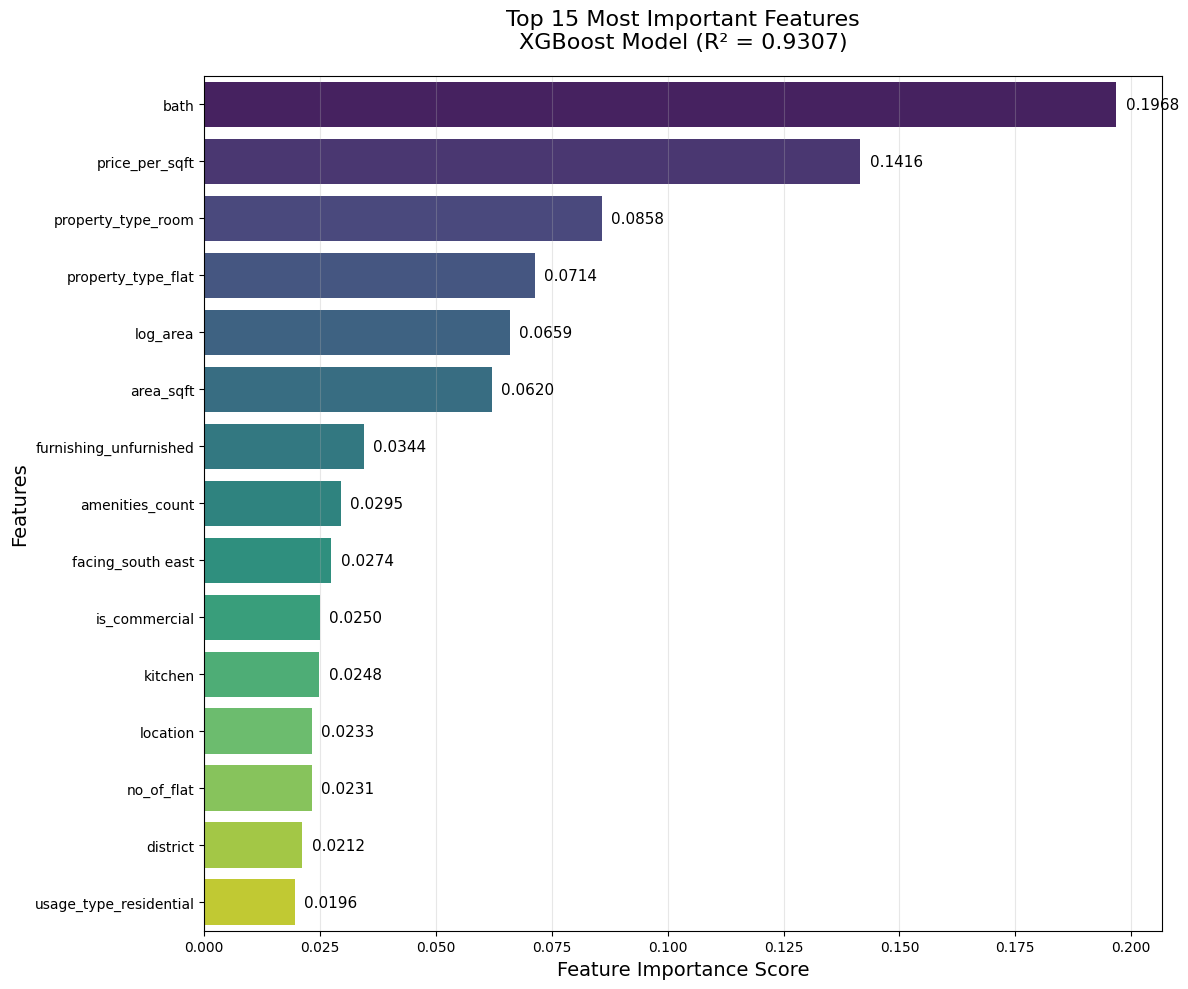

C:\Users\arjun\AppData\Local\Temp\ipykernel_8356\1886253681.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index, y=top10.values, palette='mako')


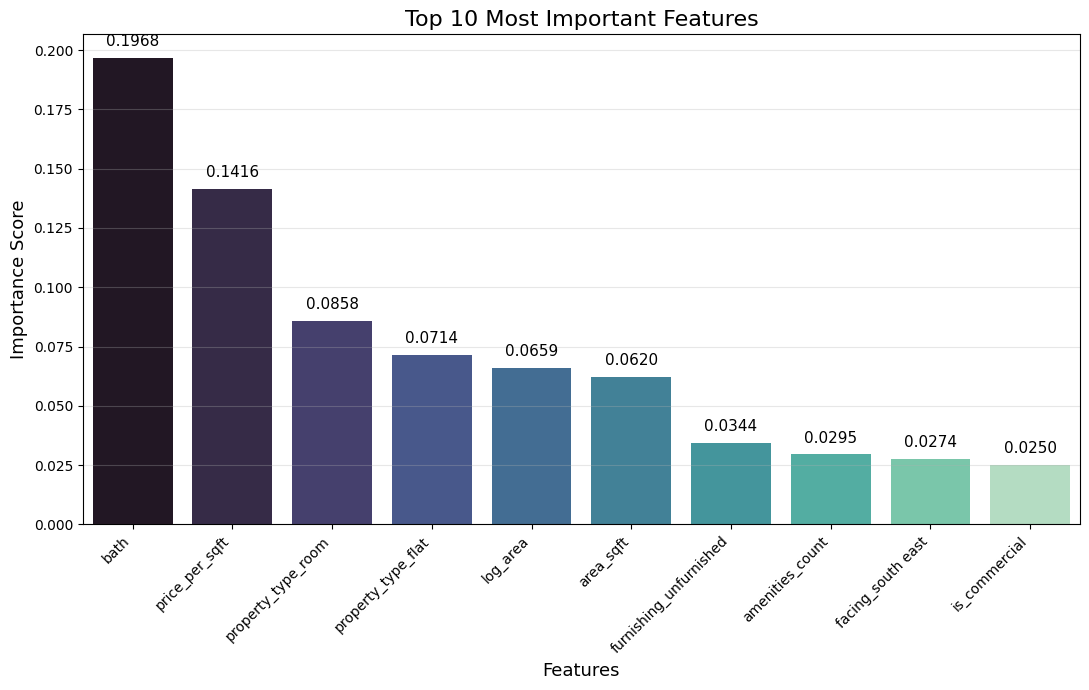

In [25]:
# ====================================> 12. Feature Importance Visualization =============


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Get feature importance from your best model
importances = pd.Series(best_model.feature_importances_, 
                       index=X.columns).sort_values(ascending=False)

# Take top 15 features
top15 = importances.head(15)

# ------------------- Plot 1: Horizontal Bar Chart (top 15) -------------------
plt.figure(figsize=(12, 10))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')

plt.title('Top 15 Most Important Features\nXGBoost Model (R² = 0.9307)', 
          fontsize=16, pad=20)
plt.xlabel('Feature Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)

# Add value labels on bars
for i, v in enumerate(top15.values):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=11)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------- Plot 2: Vertical Bar Chart (Top 10) -------------------
plt.figure(figsize=(11, 7))
top10 = importances.head(10)

sns.barplot(x=top10.index, y=top10.values, palette='mako')

plt.title('Top 10 Most Important Features', fontsize=16)
plt.xlabel('Features', fontsize=13)
plt.ylabel('Importance Score', fontsize=13)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top10.values):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
import joblib

# ✅ Save trained encoder
joblib.dump(encoder, 'target_encoder.pkl')

# ✅ Save training columns (VERY important for inference)
joblib.dump(X_train.columns.tolist(), 'train_columns.pkl')


['train_columns.pkl']